# RE3.3 · Taxonomía geométrica de discrepancias

Las predicciones de alta confianza del modelo seleccionado sobre **todo el corpus** —train por
validación cruzada (`src/kfold.py`: cinco modelos, cada uno predice el pliegue de grabaciones que
no vio), val y test con el modelo final— repartidas entre las cuatro categorías de la Tabla
`tab:taxonomia-fp` del plan: **A encuadre**, **B unidad**, **C clase**, **D región sin anotación**.
La categoría D se caracteriza geométricamente frente a las cajas anotadas de cada clase y se deja
como tabla de hallazgos para revisar en Raven. Deja en `figures/RE_3-3/` las tablas, figuras y
macros que usa `RE_3-3_taxonomia-discrepancias.tex`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import reporte
import torch
from matplotlib.axes import Axes
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter, NullFormatter
from reporte import TEXT_WIDTH_IN, number, percent
from torch import Tensor
from torchvision.ops import box_convert, box_iou

from core.config import RUNS_DIR, P
from data import cache
from data.species import LabelSet, split_label
from evaluation.evaluator import RawPredictions, path_for
from evaluation.metrics import (
    MATCH_IOU,
    Boxes,
    assignments,
    overlaps,
    rows_by_image,
    window_classes,
)
from evaluation.protocol import MIN_PRECISIONS, equalize, match, operating_point, select
from find_issues import LABEL, LOCATION, SPURIOUS, class_thresholds, find
from utils.audio import mel_to_unit, y_to_hz

OUT = reporte.out_dir("RE_3-3")
RUN = "yolo26s_v3"  # el modelo seleccionado en RE2.3: sus volcados de val y test
KFOLD = f"{RUN}_kfold5"  # sus cinco pliegues sobre train (src/kfold.py)
DUMP_PATHS = {
    cache.TRAIN: path_for(RUNS_DIR / KFOLD, KFOLD, cache.TRAIN),
    cache.VAL: path_for(RUNS_DIR / RUN, RUN, cache.VAL),
    cache.TEST: path_for(RUNS_DIR / RUN, RUN, cache.TEST),
}
A, B, C, D = "A encuadre", "B unidad", "C clase", "D sin anotación"
CATEGORIES = [A, B, C, D]
COLORS = {A: "#a05bd6", B: "#2a78d6", C: "#eda100", D: "#d03b3b"}
TP_COLOR = "#1baf7a"
COVER = 0.5  # una predicción "cubre" una anotación si tapa al menos esta fracción de su área
NEAR_S = 1.0  # una D está "junto a" una anotación de su clase si dista menos que esto
N_EXAMPLES = 2  # ventanas por categoría en el panel
N_TOP_CLASSES = 6
WINDOWS_PER_HOUR = 3600 / P.clip_hop_s
CAPTION_BOX = {"facecolor": "black", "alpha": 0.55, "pad": 1.0, "lw": 0}
pd.set_option("display.width", 160)

## 1. Volcados y punto de operación

El umbral es el del modelo final, elegido en validación con la regla de RE2.1 (máximo
*recall* con precisión ≥ 0,70); los cinco modelos del k-fold comparten receta y se les aplica
el mismo umbral. Predicción de alta confianza: la que supera ese umbral tras el postprocesado
común (NMS 0,3 por clase, cajas anidadas fuera, tope de 100 por ventana).

In [2]:
dumps = {split: RawPredictions.load(path) for split, path in DUMP_PATHS.items()}
labels = LabelSet(dumps[cache.TEST].labels)
assert all(d.labels == labels.names for d in dumps.values())
saturated = window_classes(dumps[cache.TEST].truth, len(labels))
predictions = {split: equalize(d.predictions) for split, d in dumps.items()}
chosen = select(
    match(predictions[cache.VAL], dumps[cache.VAL].truth, dumps[cache.VAL].n_images),
    MIN_PRECISIONS[0],
)
assert chosen is not None
THRESHOLD = chosen.threshold

matched = {
    split: match(predictions[split], dumps[split].truth, dumps[split].n_images) for split in dumps
}
rows = []
for split, dump in dumps.items():
    point = operating_point(matched[split], THRESHOLD)
    rows.append(
        {
            "split": split,
            "grabaciones": len(dump.recording_names),
            "ventanas": dump.n_images,
            "horas": dump.n_images / WINDOWS_PER_HOUR,
            "cajas anotadas": len(dump.truth.boxes),
            "predicciones ≥ umbral": point.n_above,
            "aciertos": point.n_tp,
            "recall": point.recall,
            "precisión": point.precision,
        }
    )
splits = pd.DataFrame(rows).set_index("split")
print(
    f"{RUN} · umbral {THRESHOLD:.2f} · {len(labels)} clases; de ventana: {[labels.name(c) for c in saturated]}"
)
splits.round(3)

yolo26s_v3 · umbral 0.11 · 25 clases; de ventana: ['as/hc', 'pt/dc']


,grabaciones,ventanas,horas,cajas anotadas,predicciones ≥ umbral,aciertos,recall,precisión
split,,,,,,,,
train,1248,21751,9.063,26938,30537,22158,0.823,0.726
val,690,9364,3.902,10114,12088,8462,0.837,0.700
test,601,7598,3.166,7931,9662,6430,0.811,0.665


## 2. Las cuatro categorías

Para cada predicción de alta confianza que **no** es un acierto del protocolo (IoU ≥ 0,3 con una
anotación de su clase que ninguna otra predicción reclamó antes), se mira qué anotaciones tiene
debajo en su ventana:

- **B unidad**: tiene una anotación de su clase con IoU ≥ 0,3 pero ya reclamada por otra
  predicción (una anotación partida en varias predicciones), o cubre ≥ 50 % del área de dos o
  más anotaciones de su clase (varias anotaciones fundidas en una predicción);
- **C clase**: tiene una anotación de otra clase con IoU ≥ 0,3 (encuadre correcto, etiqueta
  incorrecta);
- **A encuadre**: solapa una anotación de su clase con IoU < 0,3;
- **D región sin anotación**: no toca ninguna anotación de su clase y ninguna de otra clase con
  IoU ≥ 0,3.

Se evalúan en ese orden. Las de ventana (`as/hc`, `pt/dc`) se excluyen: su caja ocupa la ventana
y la geometría no distingue nada.

In [3]:
def categorize(split: str) -> pd.DataFrame:
    dump, preds = dumps[split], predictions[split]
    truth = dump.truth
    n_above = matched[split].above(THRESHOLD)
    above = preds.select(torch.arange(n_above))
    found = matched[split].found[:n_above] == 1
    claimed = {t for _, t in assignments(overlaps(above, truth, class_aware=True), MATCH_IOU)}
    p_xyxy = box_convert(above.boxes, "cxcywh", "xyxy")
    t_xyxy = box_convert(truth.boxes, "cxcywh", "xyxy")
    truth_rows = rows_by_image(truth.image_ids)
    t_area = (t_xyxy[:, 2] - t_xyxy[:, 0]) * (t_xyxy[:, 3] - t_xyxy[:, 1])

    records = []
    for row in range(n_above):
        label = int(above.labels[row])
        record = {
            "split": split,
            "fila": row,
            "ventana": int(above.image_ids[row]),
            "grabación": dump.recording_names[int(dump.recordings[int(above.image_ids[row])])],
            "clase": labels.name(label),
            "score": float(above.scores[row]),
            "categoría": "acierto" if found[row] else D,
            "anotación": None,
            "iou": 0.0,
        }
        rows_t = truth_rows.get(record["ventana"], [])
        if not found[row] and rows_t:
            t = torch.tensor(rows_t)
            iou = box_iou(p_xyxy[row : row + 1], t_xyxy[t])[0]
            same = truth.labels[t] == label
            inter = (
                (
                    torch.min(p_xyxy[row, 2:], t_xyxy[t][:, 2:])
                    - torch.max(p_xyxy[row, :2], t_xyxy[t][:, :2])
                )
                .clamp(min=0)
                .prod(dim=1)
            )
            covered = same & (inter / t_area[t].clamp(min=1e-9) >= COVER)
            best_same = int((iou * same).argmax()) if same.any() else None
            best_other = int((iou * ~same).argmax()) if (~same).any() else None
            if (
                best_same is not None
                and iou[best_same] >= MATCH_IOU
                and int(t[best_same]) in claimed
            ):
                record.update(
                    {"categoría": B, "anotación": int(t[best_same]), "iou": float(iou[best_same])}
                )
            elif best_other is not None and iou[best_other] >= MATCH_IOU:
                record.update(
                    {"categoría": C, "anotación": int(t[best_other]), "iou": float(iou[best_other])}
                )
            elif int(covered.sum()) >= 2:
                record.update(
                    {"categoría": B, "anotación": int(t[best_same]), "iou": float(iou[best_same])}
                )
            elif best_same is not None and iou[best_same] > 0:
                record.update(
                    {"categoría": A, "anotación": int(t[best_same]), "iou": float(iou[best_same])}
                )
        records.append(record)
    table = pd.DataFrame(records)
    table["anotada como"] = [
        labels.name(int(truth.labels[int(a)])) if pd.notna(a) else None for a in table["anotación"]
    ]
    return table


confident = pd.concat([categorize(split) for split in dumps], ignore_index=True)
confident = confident[~confident.clase.isin(labels.name(c) for c in saturated)]
discrepancies = confident[confident["categoría"] != "acierto"]
taxonomy = pd.crosstab(confident.split, confident["categoría"]).reindex(
    index=list(dumps), columns=["acierto", *CATEGORIES], fill_value=0
)
taxonomy["predicciones"] = taxonomy.sum(axis=1)
taxonomy["discrepancias"] = taxonomy[CATEGORIES].sum(axis=1)
taxonomy["D por hora"] = taxonomy[D] / splits["horas"]
taxonomy.loc["corpus"] = taxonomy.sum()
taxonomy.loc["corpus", "D por hora"] = taxonomy.loc["corpus", D] / splits["horas"].sum()
share = 100 * taxonomy[CATEGORIES].div(taxonomy["discrepancias"], axis=0)
taxonomy.round(1)

categoría,acierto,A encuadre,B unidad,C clase,D sin anotación,predicciones,discrepancias,D por hora
split,,,,,,,,
train,13680.0,381.0,37.0,467.0,6653.0,21218.0,7538.0,734.1
val,5302.0,130.0,20.0,170.0,2762.0,8384.0,3082.0,707.9
test,3982.0,170.0,21.0,146.0,2449.0,6768.0,2786.0,773.6
corpus,22964.0,681.0,78.0,783.0,11864.0,36370.0,13406.0,735.5


In [4]:
rows_tex = []
for split in taxonomy.index:
    t = taxonomy.loc[split]
    rows_tex.append(
        [
            split,
            number(t["predicciones"]),
            number(t["acierto"]),
            *(f"{number(t[c])} ({number(share.loc[split, c], 1)}\\,\\%)" for c in CATEGORIES),
            number(t["D por hora"], 1),
        ]
    )
reporte.write_rows(OUT / "taxonomia.tex", rows_tex)
share.round(1)

categoría,A encuadre,B unidad,C clase,D sin anotación
split,,,,
train,5.1,0.5,6.2,88.3
val,4.2,0.6,5.5,89.6
test,6.1,0.8,5.2,87.9
corpus,5.1,0.6,5.8,88.5


### 2.1. Por clase

Discrepancias de cada clase en el corpus entero, y qué fracción de sus predicciones confiadas son
D: una clase con muchas D respecto de sus aciertos es una clase cuyas anotaciones el modelo
contradice a menudo.

In [5]:
by_class = pd.crosstab(confident.clase, confident["categoría"]).reindex(
    columns=["acierto", *CATEGORIES], fill_value=0
)
by_class["predicciones"] = by_class.sum(axis=1)
by_class["% D"] = 100 * by_class[D] / by_class["predicciones"]
by_class = by_class.sort_values("% D", ascending=False)
reporte.write_rows(
    OUT / "por_clase.tex",
    [
        [
            f"\\code{{{name}}}",
            *(number(r[c]) for c in ("predicciones", "acierto", *CATEGORIES)),
            number(r["% D"], 1),
        ]
        for name, r in by_class.iterrows()
    ],
)
by_class.round(1)

categoría,acierto,A encuadre,B unidad,C clase,D sin anotación,predicciones,% D
clase,,,,,,,
sb/ppc,1448,55,4,108,1627,3242,50.2
sb/spc,978,51,29,57,1117,2232,50.0
sm/pc,288,11,1,17,279,596,46.8
lw/vc,159,0,0,11,144,314,45.9
sb/sc,117,2,4,53,145,321,45.2
lw/trino,876,26,7,48,786,1743,45.1
sb/pcc,344,17,1,84,318,764,41.6
sm/sc,103,14,0,38,101,256,39.5
lw/sqc,210,5,0,4,133,352,37.8


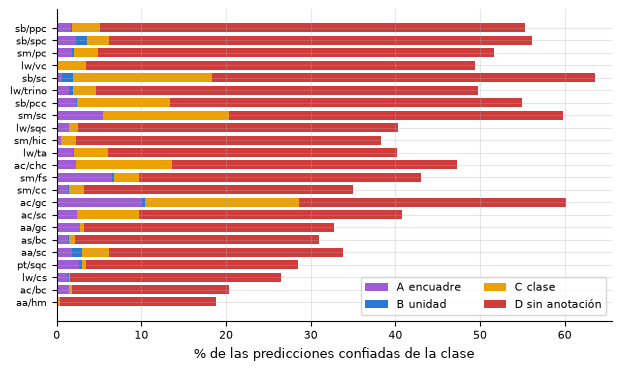

In [6]:
fig, ax = plt.subplots(figsize=(TEXT_WIDTH_IN, 3.6), constrained_layout=True)
order = by_class.index[::-1]
left = np.zeros(len(order))
for category in CATEGORIES:
    values = 100 * by_class.loc[order, category] / by_class.loc[order, "predicciones"]
    ax.barh(order, values, left=left, color=COLORS[category], label=category, height=0.72)
    left += values.to_numpy()
ax.set(
    xlabel="% de las predicciones confiadas de la clase", xlim=(0, max(50, float(left.max()) + 2))
)
ax.tick_params(axis="y", labelsize=7)
ax.legend(loc="lower right", ncol=2)
reporte.save_figure(fig, OUT / "por_clase")
plt.show()

## 3. La categoría D frente a las anotaciones

Si las D se parecen a las cajas anotadas de su clase —misma duración, misma banda, puntuación
comparable a la de los aciertos— y aparecen junto a llamadas anotadas de esa clase, son indicio de
eventos que la referencia omite; si no, de falsos positivos. Tres medidas por clase:

- **compatible**: duración y ancho de banda dentro del rango intercuartílico ampliado
  (P5–P95) de las cajas anotadas de la clase en train;
- **junto a su clase**: en la misma grabación hay una anotación de su clase a menos de 1 s;
- **score**: mediana de las D frente a la de los aciertos de la clase.

In [7]:
def geometry(boxes: Tensor) -> pd.DataFrame:
    xyxy = box_convert(boxes, "cxcywh", "xyxy").numpy()
    return pd.DataFrame(
        {
            "duración (s)": (xyxy[:, 2] - xyxy[:, 0]) * P.clip_len_s,
            "banda (Hz)": y_to_hz(xyxy[:, 3], P) - y_to_hz(xyxy[:, 1], P),
        }
    )


train_truth = dumps[cache.TRAIN].truth
annotated = geometry(train_truth.boxes)
annotated["clase"] = [labels.name(int(c)) for c in train_truth.labels]
bounds = annotated.groupby("clase").quantile([0.05, 0.95]).unstack()

d_rows = discrepancies[discrepancies["categoría"] == D]
d_geometry = pd.concat(
    [
        geometry(predictions[split].boxes[torch.tensor(rows.fila.to_numpy())]).set_index(rows.index)
        for split, rows in d_rows.groupby("split")
    ]
)
d_rows = d_rows.join(d_geometry)
d_rows["compatible"] = [
    bounds.loc[c, ("duración (s)", 0.05)] <= d <= bounds.loc[c, ("duración (s)", 0.95)]
    and bounds.loc[c, ("banda (Hz)", 0.05)] <= b <= bounds.loc[c, ("banda (Hz)", 0.95)]
    for c, d, b in zip(d_rows.clase, d_rows["duración (s)"], d_rows["banda (Hz)"], strict=True)
]
print(
    f"{len(d_rows)} predicciones D en el corpus; {100 * d_rows.compatible.mean():.0f} % geométricamente compatibles con su clase"
)

11864 predicciones D en el corpus; 73 % geométricamente compatibles con su clase


In [8]:
# En tiempo de grabación: distancia de cada D a la anotación más cercana de su clase.
sources = {split: cache.sources(split, dumps[split].n_images) for split in dumps}


def recording_spans(split: str, boxes: Boxes, rows: Tensor | None = None) -> pd.DataFrame:
    rows = torch.arange(len(boxes.boxes)) if rows is None else rows
    starts = torch.tensor(sources[split].clip_start_s)[boxes.image_ids[rows].long()]
    xyxy = box_convert(boxes.boxes[rows], "cxcywh", "xyxy")
    return pd.DataFrame(
        {
            "grabación": [
                sources[split].recordings[sources[split].recording_of_window[int(i)]]
                for i in boxes.image_ids[rows]
            ],
            "clase": [labels.name(int(c)) for c in boxes.labels[rows]],
            "inicio": (starts + xyxy[:, 0] * P.clip_len_s).numpy(),
            "fin": (starts + xyxy[:, 2] * P.clip_len_s).numpy(),
            "f mín (Hz)": y_to_hz(xyxy[:, 1].numpy(), P),
            "f máx (Hz)": y_to_hz(xyxy[:, 3].numpy(), P),
        }
    )


annotations_rec = pd.concat(
    [recording_spans(split, dumps[split].truth) for split in dumps], ignore_index=True
)
by_recording_class = {key: group for key, group in annotations_rec.groupby(["grabación", "clase"])}


def gap_to_class(recording: str, name: str, start: float, end: float) -> float:
    group = by_recording_class.get((recording, name))
    if group is None:
        return float("inf")
    gaps = np.maximum(group.inicio.to_numpy() - end, start - group.fin.to_numpy())
    return float(np.clip(gaps, 0, None).min())


d_spans = pd.concat(
    [
        recording_spans(split, predictions[split], torch.tensor(rows.fila.to_numpy())).set_index(
            rows.index
        )
        for split, rows in d_rows.groupby("split")
    ]
)
d_rows = d_rows.join(d_spans[["inicio", "fin", "f mín (Hz)", "f máx (Hz)"]])
d_rows["hueco a su clase (s)"] = [
    gap_to_class(r, c, s, e)
    for r, c, s, e in zip(d_rows["grabación"], d_rows.clase, d_rows.inicio, d_rows.fin, strict=True)
]
d_rows["junto a su clase"] = d_rows["hueco a su clase (s)"] <= NEAR_S
d_rows["grabación con su clase"] = np.isfinite(d_rows["hueco a su clase (s)"])
print(
    f"{100 * d_rows['junto a su clase'].mean():.0f} % de las D están a menos de {NEAR_S:g} s de una anotación de su clase; "
    f"{100 * d_rows['grabación con su clase'].mean():.0f} % en una grabación que tiene anotaciones de su clase"
)

37 % de las D están a menos de 1 s de una anotación de su clase; 71 % en una grabación que tiene anotaciones de su clase


In [9]:
tp_rows = confident[confident["categoría"] == "acierto"]
d_by_class = (
    d_rows.groupby("clase")
    .agg(
        D=("fila", "size"),
        compatible=("compatible", "mean"),
        junto=("junto a su clase", "mean"),
        en_grabacion_con_clase=("grabación con su clase", "mean"),
        score_D=("score", "median"),
    )
    .join(tp_rows.groupby("clase").agg(aciertos=("fila", "size"), score_TP=("score", "median")))
    .join(by_class["% D"])
    .sort_values("D", ascending=False)
)
d_by_class[["compatible", "junto", "en_grabacion_con_clase"]] *= 100
reporte.write_rows(
    OUT / "categoria_d.tex",
    [
        [
            f"\\code{{{name}}}",
            number(r["D"]),
            number(r["aciertos"]) if not pd.isna(r["aciertos"]) else "0",
            number(r["% D"], 1),
            number(r["compatible"], 0),
            number(r["junto"], 0),
            number(r["score_D"], 2),
            number(r["score_TP"], 2) if not pd.isna(r["score_TP"]) else "--",
        ]
        for name, r in d_by_class.iterrows()
    ],
)
d_by_class.round(2)

,D,compatible,junto,en_grabacion_con_clase,score_D,aciertos,score_TP,% D
clase,,,,,,,,
sm/cc,1679,78.86,37.40,70.04,0.30,3438,0.55,31.77
sb/ppc,1627,81.75,24.77,77.07,0.29,1448,0.50,50.19
lw/cs,1352,56.29,50.00,87.43,0.39,3972,0.75,25.00
sb/spc,1117,87.38,28.74,70.01,0.29,978,0.48,50.04
as/bc,1091,68.10,54.63,72.32,0.31,2609,0.71,28.85
ac/bc,935,62.57,72.30,89.63,0.39,3994,0.69,18.63
lw/trino,786,75.57,26.34,75.70,0.37,876,0.65,45.09
aa/gc,509,80.35,49.90,87.62,0.33,1156,0.62,29.59
sm/fs,501,69.46,31.74,45.91,0.38,855,0.74,33.38


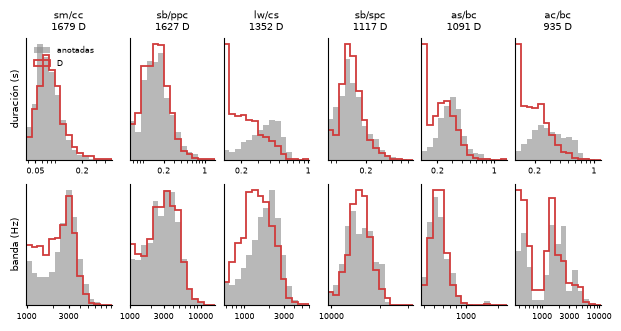

In [10]:
top = d_by_class.index[:N_TOP_CLASSES].tolist()
TICKS = {"duración (s)": [0.05, 0.2, 1, 5], "banda (Hz)": [300, 1000, 3000, 10000]}
fig, axes = plt.subplots(2, len(top), figsize=(TEXT_WIDTH_IN, 3.2), constrained_layout=True)
for column, name in enumerate(top):
    ann = annotated[annotated.clase == name]
    dd = d_rows[d_rows.clase == name]
    for row, measure in enumerate(("duración (s)", "banda (Hz)")):
        ax = axes[row, column]
        lo, hi = ann[measure].quantile([0.005, 0.995])
        bins = np.geomspace(max(lo, 1e-2), max(hi, lo * 1.1) * 1.5, 16)
        ax.hist(
            ann[measure].clip(bins[0], bins[-1]),
            bins=bins,
            density=True,
            color="#8a8a8a",
            alpha=0.6,
            label="anotadas",
        )
        ax.hist(
            dd[measure].clip(bins[0], bins[-1]),
            bins=bins,
            density=True,
            histtype="step",
            color=COLORS[D],
            lw=1.3,
            label="D",
        )
        ax.set(xscale="log", yticks=[], xlim=(bins[0], bins[-1]))
        ax.set_xticks([t for t in TICKS[measure] if bins[0] <= t <= bins[-1]])
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
        ax.tick_params(labelsize=6, length=2)
        ax.grid(False)
        if row == 0:
            ax.set_title(f"{name}\n{len(dd)} D", fontsize=7)
        if column == 0:
            ax.set_ylabel(measure, fontsize=7.5)
axes[0, 0].legend(fontsize=6, loc="upper left", frameon=False)
reporte.save_figure(fig, OUT / "categoria_d")
plt.show()

### 3.1. Dónde se concentran

Grabaciones que acumulan las D: si unas pocas concentran la mayoría, la revisión se acota. Se
escribe la tabla de hallazgos completa (`hallazgos_corpus.csv`), con tiempos en segundos y
frecuencias en Hz, para abrirla en Raven o en el visor sobre cada grabación.

In [11]:
per_recording = d_rows.groupby("grabación").size().sort_values(ascending=False)
cumulative = per_recording.cumsum() / per_recording.sum()
n_half = int((cumulative < 0.5).sum()) + 1
n_recordings = sum(len(d.recording_names) for d in dumps.values())
print(
    f"{len(per_recording)} de {n_recordings} grabaciones tienen alguna D; "
    f"{n_half} grabaciones ({100 * n_half / n_recordings:.1f} %) reúnen la mitad"
)
findings = d_rows[
    [
        "split",
        "grabación",
        "clase",
        "score",
        "inicio",
        "fin",
        "f mín (Hz)",
        "f máx (Hz)",
        "duración (s)",
        "banda (Hz)",
        "compatible",
        "hueco a su clase (s)",
    ]
].sort_values(["grabación", "inicio"])
findings.to_csv(OUT / "hallazgos_corpus.csv", index=False)
per_recording.head(10).to_frame("D")

1604 de 2539 grabaciones tienen alguna D; 236 grabaciones (9.3 %) reúnen la mitad


,D
grabación,
/home/fcandia/tesis-primate/data/raw/bolivian_squirrel_monkey__SB/20240202_165553.wav,103
/home/fcandia/tesis-primate/data/raw/night_monkey__AA/20240117_051239.wav,100
/home/fcandia/tesis-primate/data/raw/weddells_saddleBack_tamarin__LW/20240207_065212.wav,99
/home/fcandia/tesis-primate/data/raw/bolivian_squirrel_monkey__SB/20231230_171342.wav,94
/home/fcandia/tesis-primate/data/raw/weddells_saddleBack_tamarin__LW/20240313_165431.wav,65
/home/fcandia/tesis-primate/data/raw/weddells_saddleBack_tamarin__LW/20240405_065325.wav,62
/home/fcandia/tesis-primate/data/raw/bolivian_squirrel_monkey__SB/20240522_071702.wav,61
/home/fcandia/tesis-primate/data/raw/bolivian_squirrel_monkey__SB/20231228_081246.wav,61
/home/fcandia/tesis-primate/data/raw/bolivian_squirrel_monkey__SB/20240219_104053.wav,61


### 3.2. Contraste con las tablas crudas

Cada D frente a la tabla de Raven de su grabación en `data/unified/` (la unión de las tablas de
todas las copias de la grabación, sin limpiar), con `find_issues.contrast`: la fila cruda de mayor
IoU bajo la predicción (recortada a la ventana y en el espacio del modelo, como el emparejamiento)
y qué hizo la limpieza de RE1.1 con ella. `sin fila`: nada anotado debajo; si es un evento, el
anotador no lo marcó. `descartada`: había una fila pero la limpieza la quitó (ruido, caja
degenerada). `en revisión`: quedó en `cleaned/` con `requires_review` (tipo fuera del vocabulario o
vacío, especie escrita distinta de la carpeta) y el experimento no la usa. `sin clase`: quedó pero
su especie/llamada no entró al conjunto (`excluded_labels`, menos de 100 cajas). `limpia`: hay una anotación del conjunto
debajo que la ventana recortó o que quedó con IoU < 0,3 en la ventana. Sólo las `sin fila` son
candidatas a omisión.


In [12]:
from core.config import UNIFIED_DIR  # noqa: E402
from data.raven import CLEANED_BOX_COLUMNS  # noqa: E402
from find_issues import (  # noqa: E402
    CLEAN,
    DROPPED,
    EXCLUDED,
    NO_ROW,
    RAW_CALL,
    RAW_IOU,
    RAW_LABEL,
    RAW_STATE,
    RECORDING,
    REVIEW,
    STATES,
    WINDOW_START,
    contrast,
)

begin, end, low, high = CLEANED_BOX_COLUMNS
d_windows = d_rows.rename(
    columns={
        "grabación": RECORDING,
        "inicio": begin,
        "fin": end,
        "f mín (Hz)": low,
        "f máx (Hz)": high,
    }
)
d_windows[WINDOW_START] = [
    sources[split].clip_start_s[window]
    for split, window in zip(d_rows.split, d_rows.ventana, strict=True)
]
raw_d = contrast(d_windows, labels, UNIFIED_DIR)
d_rows = d_rows.join(raw_d[[RAW_IOU, RAW_CALL, RAW_LABEL, RAW_STATE]])
raw_call = d_rows[RAW_CALL].fillna("").str.strip().str.lower().replace("", "(vacío)")
d_rows["fila cruda"] = np.where(
    d_rows[RAW_STATE] == DROPPED, DROPPED + ", " + raw_call, d_rows[RAW_STATE]
)
by_state = d_rows["fila cruda"].value_counts()
reporte.write_rows(
    OUT / "contraste.tex",
    [[state, number(n), percent(n / len(d_rows), 1)] for state, n in by_state.items()],
)
by_state_class = (
    pd.crosstab(d_rows.clase, d_rows[RAW_STATE])
    .reindex(columns=STATES, fill_value=0)
    .loc[d_by_class.index]
)
reporte.write_rows(
    OUT / "contraste_clase.tex",
    [
        [
            f"\\code{{{name}}}",
            number(r.sum()),
            *(
                percent(r[s] / r.sum(), 0) if r.sum() else "--"
                for s in (NO_ROW, DROPPED, REVIEW, EXCLUDED, CLEAN)
            ),
        ]
        for name, r in by_state_class.head(N_TOP_CLASSES).iterrows()
    ],
)
findings = findings.join(d_rows[[RAW_STATE, RAW_LABEL, RAW_CALL]])
findings.to_csv(OUT / "hallazgos_corpus.csv", index=False)
print(
    f"{len(d_rows)} D: {100 * (d_rows[RAW_STATE] == NO_ROW).mean():.0f} % sin ninguna fila cruda debajo"
)
display(
    pd.concat(
        [by_state.to_frame("D"), (100 * by_state / len(d_rows)).round(1).to_frame("%")], axis=1
    )
)
by_state_class

11864 D: 90 % sin ninguna fila cruda debajo


,D,%
fila cruda,,
sin fila,10642,89.7
limpia,1000,8.4
en revisión,132,1.1
sin clase,90,0.8


raw_estado,sin fila,descartada,en revisión,sin clase,limpia
clase,,,,,
sm/cc,1635,0,17,14,13
sb/ppc,1550,0,10,5,62
lw/cs,1046,0,8,15,283
sb/spc,1100,0,2,0,15
as/bc,907,0,8,0,176
ac/bc,671,0,11,3,250
lw/trino,720,0,16,20,30
aa/gc,494,0,4,0,11
sm/fs,449,0,4,18,30


## 4. El otro lado: anotaciones que el modelo contradice

Con las categorías de `find_issues.py` (CLOD): `spurious`, anotación que ninguna predicción de
ninguna clase toca (el modelo ve fondo); `label`, anotación cubierta por una predicción confiada
de otra clase y no por una de la suya (el umbral de confianza es por clase: el score medio de sus
anotaciones); `location`, anotación acertada pero con IoU < 0,6. Una anotación con predicciones
poco confiadas de su clase no es hallazgo. Es el espejo de A, B y C visto desde la anotación.


In [13]:
issue_frames = []
for split, dump in dumps.items():
    thresholds = class_thresholds(predictions[split], dump.truth, len(labels))
    table = pd.DataFrame(
        [
            {"split": split, "clase": labels.name(f.label), "hallazgo": f.issue}
            for f in find(predictions[split], dump.truth, thresholds)
        ]
    )
    issue_frames.append(table)
issues = pd.concat(issue_frames, ignore_index=True)
issues = issues[issues.hallazgo.isin([SPURIOUS, LABEL, LOCATION])]
n_annotated = pd.Series(
    torch.cat([d.truth.labels for d in dumps.values()]).long().tolist()
).value_counts()
n_annotated.index = [labels.name(i) for i in n_annotated.index]
issues_by_class = pd.crosstab(issues.clase, issues.hallazgo).reindex(
    columns=[SPURIOUS, LABEL, LOCATION], fill_value=0
)
issues_by_class.insert(0, "anotadas", n_annotated.reindex(issues_by_class.index))
for column in (SPURIOUS, LABEL, LOCATION):
    issues_by_class[f"% {column}"] = 100 * issues_by_class[column] / issues_by_class["anotadas"]
issues_by_class = issues_by_class.sort_values("% spurious", ascending=False)
reporte.write_rows(
    OUT / "anotaciones.tex",
    [
        [
            f"\\code{{{name}}}",
            number(r["anotadas"]),
            *(
                f"{number(r[c])} ({number(r[f'% {c}'], 1)}\\,\\%)"
                for c in (SPURIOUS, LABEL, LOCATION)
            ),
        ]
        for name, r in issues_by_class.iterrows()
    ],
)
issues_by_class.round(1)

hallazgo,anotadas,spurious,label,location,% spurious,% label,% location
clase,,,,,,,
sm/sc,324,119,9,14,36.7,2.8,4.3
sm/fs,1332,318,9,59,23.9,0.7,4.4
ac/gc,318,74,19,42,23.3,6.0,13.2
sm/pc,472,84,1,38,17.8,0.2,8.1
aa/gc,1536,268,4,50,17.4,0.3,3.3
ac/sc,313,45,36,22,14.4,11.5,7.0
sb/sc,209,30,2,26,14.4,1.0,12.4
as/bc,3694,480,6,311,13.0,0.2,8.4
sb/ppc,2333,242,80,175,10.4,3.4,7.5


### 4.1. Las anotaciones contradichas frente a la tabla cruda

La tabla de hallazgos que escribe `find_issues.py` (un hallazgo por caja, fundidos los repetidos
entre ventanas solapadas), contrastada con la fila cruda: si la `Species` que escribió el anotador
difiere de la carpeta (las anotaciones discordantes de RE1.1) y, en los `label`, si la especie que
sugiere el modelo es la que escribió el anotador.


In [14]:
from find_issues import ISSUE, RAW_FOLDER, RAW_SPECIES, SUGGESTION, to_table  # noqa: E402

clod = pd.concat(
    [
        to_table(
            find(
                predictions[split],
                dump.truth,
                class_thresholds(predictions[split], dump.truth, len(labels)),
            ),
            dump,
            labels,
        ).assign(split=split)
        for split, dump in dumps.items()
    ],
    ignore_index=True,
)
clod = contrast(
    clod[clod[ISSUE].isin([SPURIOUS, LABEL, LOCATION])].reset_index(drop=True), labels, UNIFIED_DIR
)
written = clod[RAW_SPECIES].fillna("").str.strip().str.lower()
folder = clod[RAW_FOLDER].fillna("").str.strip().str.lower()
clod["especie escrita"] = np.select(
    [written == "", written == folder], ["vacía", "= carpeta"], "≠ carpeta"
)
# Discordantes: la especie escrita no es la de la carpeta. En los `label`, ¿el modelo sugiere
# justamente la especie escrita?
discordant = clod[clod["especie escrita"] == "≠ carpeta"]
label_rows = discordant[discordant[ISSUE] == LABEL]
suggested_species = label_rows[SUGGESTION].map(
    lambda s: split_label(s)[0] if isinstance(s, str) else None
)
n_label_written = int((suggested_species == written[label_rows.index]).sum())
n_written_differs = len(discordant)
print(
    f"{n_written_differs} hallazgos sobre filas con especie escrita distinta de la carpeta "
    f"({len(label_rows)} label); en {n_label_written} label el modelo sugiere la especie escrita"
)
pd.crosstab(clod[ISSUE], clod["especie escrita"])

21 hallazgos sobre filas con especie escrita distinta de la carpeta (5 label); en 0 label el modelo sugiere la especie escrita


especie escrita,= carpeta,≠ carpeta
Hallazgo,,
label,256,5
location,2208,12
spurious,1819,4


## 5. Ejemplos

Dos ventanas de test por categoría: anotaciones en blanco; predicciones confiadas en color según
su categoría (acierto en verde).

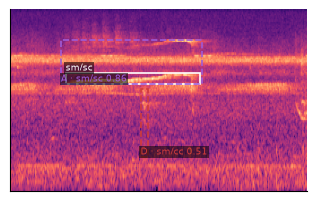

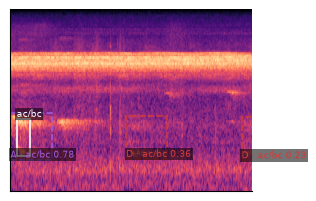

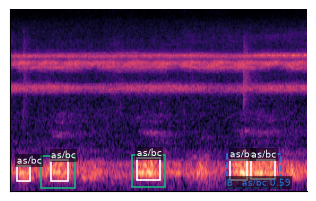

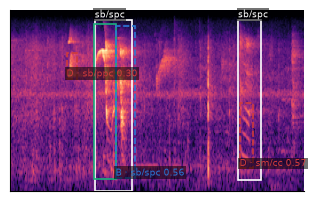

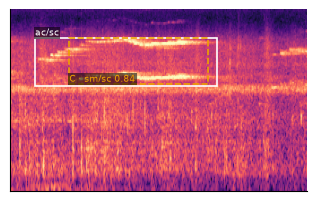

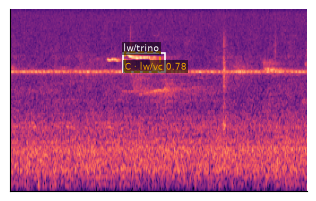

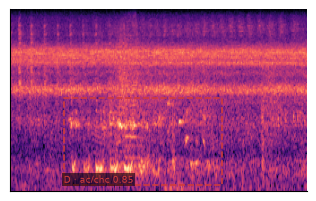

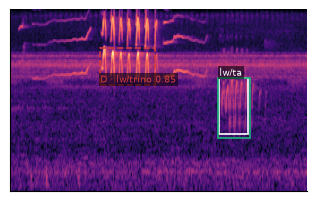

1584

In [15]:
windows = torch.load(
    cache.split_path(cache.TEST), map_location="cpu", weights_only=False, mmap=True
)
db_low, db_high = cache.db_range()
test_conf = confident[confident.split == cache.TEST]
test_preds = predictions[cache.TEST]
test_truth = dumps[cache.TEST].truth
category_of_row = dict(zip(test_conf.fila, test_conf["categoría"], strict=True))


def rectangle(
    ax: Axes, box: Tensor, color: str, style: str, text: str = "", top: bool = True
) -> None:
    cx, cy, w, h = box.tolist()
    x0, y0 = (cx - w / 2) * P.clip_len_s, cy - h / 2
    ax.add_patch(Rectangle((x0, y0), w * P.clip_len_s, h, fill=False, ec=color, ls=style, lw=1.2))
    if text:
        ax.text(
            x0,
            y0 + h if top else y0,
            text,
            color=color,
            fontsize=6.5,
            va="bottom",
            bbox=CAPTION_BOX,
        )


def draw_window(ax: Axes, image_id: int) -> None:
    ax.imshow(
        mel_to_unit(windows["images"][image_id][0], db_low, db_high),
        origin="lower",
        aspect="auto",
        cmap="magma",
        extent=(0, P.clip_len_s, 0, 1),
    )
    for row in (test_truth.image_ids == image_id).nonzero().flatten().tolist():
        rectangle(ax, test_truth.boxes[row], "white", "-", labels.name(int(test_truth.labels[row])))
    for row, category in category_of_row.items():
        if int(test_preds.image_ids[row]) != image_id:
            continue
        color = TP_COLOR if category == "acierto" else COLORS[category]
        text = (
            ""
            if category == "acierto"
            else f"{category[0]} · {labels.name(int(test_preds.labels[row]))} {float(test_preds.scores[row]):.2f}"
        )
        rectangle(
            ax,
            test_preds.boxes[row],
            color,
            "-" if category == "acierto" else "--",
            text,
            top=False,
        )
    ax.set(xticks=[], yticks=[])
    ax.grid(False)


chosen_windows = []
for category in CATEGORIES:
    rows = (
        test_conf[test_conf["categoría"] == category]
        .sort_values("score", ascending=False)
        .drop_duplicates("grabación")
    )
    chosen_windows += [(category, int(v)) for v in rows.ventana.head(N_EXAMPLES)]
subfigures = []
for k, (category, image_id) in enumerate(chosen_windows, start=1):
    fig, ax = plt.subplots(figsize=(TEXT_WIDTH_IN / 2, 1.9), constrained_layout=True)
    draw_window(ax, image_id)
    reporte.save_figure(fig, OUT / f"ejemplo_{k}")
    plt.show()
    recording = Path(
        dumps[cache.TEST].recording_names[int(dumps[cache.TEST].recordings[image_id])]
    ).name.replace("_", "\\_")
    subfigures.append(
        "\\begin{subfigure}[t]{0.49\\textwidth}\n"
        f"    \\includegraphics[width=\\linewidth]{{figures/RE_3-3/ejemplo_{k}}}\n"
        f"    \\caption{{{category}: \\code{{{recording}}}, ventana {image_id}}}\n"
        "\\end{subfigure}"
    )
glue = ["\\\\[1.5ex]\n" if (i + 1) % 2 == 0 else "\\hfill\n" for i in range(len(subfigures) - 1)]
(OUT / "ejemplos.tex").write_text(
    "% generado por el cuaderno homónimo; no editar\n"
    + "".join(part for pair in zip(subfigures, [*glue, "\n"], strict=True) for part in pair)
)

## 6. Cifras para el documento

In [16]:
corpus = taxonomy.loc["corpus"]
top_d = d_by_class.index[:3].tolist()
values = {
    "run": RUN.replace("_", "\\_"),
    "kfold": KFOLD.replace("_", "\\_"),
    "threshold": number(THRESHOLD, 2),
    "n_recordings": number(n_recordings),
    "hours": number(splits["horas"].sum(), 1),
    "n_annotated": number(len(annotations_rec)),
    "n_confident": number(corpus["predicciones"]),
    "n_hits": number(corpus["acierto"]),
    "n_discrepancies": number(corpus["discrepancias"]),
    "pct_discrepancies": percent(corpus["discrepancias"] / corpus["predicciones"]),
    "n_a": number(corpus[A]),
    "n_b": number(corpus[B]),
    "n_c": number(corpus[C]),
    "n_d": number(corpus[D]),
    "pct_a": percent(share.loc["corpus", A] / 100, 0),
    "pct_b": percent(share.loc["corpus", B] / 100, 0),
    "pct_c": percent(share.loc["corpus", C] / 100, 0),
    "pct_d": percent(share.loc["corpus", D] / 100, 0),
    "d_per_hour": number(corpus["D por hora"], 1),
    "pct_d_compatible": percent(d_rows.compatible.mean(), 0),
    "pct_d_near": percent(d_rows["junto a su clase"].mean(), 0),
    "pct_d_with_class": percent(d_rows["grabación con su clase"].mean(), 0),
    "score_d": number(d_rows.score.median(), 2),
    "score_tp": number(tp_rows.score.median(), 2),
    "top_d_classes": ", ".join(f"\\code{{{c}}}" for c in top_d),
    "top_d_share": percent(d_by_class.loc[top_d, "D"].sum() / len(d_rows), 0),
    "n_recordings_with_d": number(len(per_recording)),
    "n_half": number(n_half),
    "pct_half": percent(n_half / n_recordings, 1),
    "pct_c_same_species": percent(
        np.mean(
            [
                split_label(a)[0] == split_label(b)[0]
                for a, b in zip(
                    discrepancies[discrepancies["categoría"] == C].clase,
                    discrepancies[discrepancies["categoría"] == C]["anotada como"],
                    strict=True,
                )
            ]
        )
        if (discrepancies["categoría"] == C).any()
        else 0.0,
        0,
    ),
    "n_spurious": number(int((issues.hallazgo == SPURIOUS).sum())),
    "n_label": number(int((issues.hallazgo == LABEL).sum())),
    "n_location": number(int((issues.hallazgo == LOCATION).sum())),
    "train_recall": number(splits.loc[cache.TRAIN, "recall"], 3),
    "train_precision": number(splits.loc[cache.TRAIN, "precisión"], 3),
    "test_recall": number(splits.loc[cache.TEST, "recall"], 3),
    "test_precision": number(splits.loc[cache.TEST, "precisión"], 3),
    "match_iou": number(MATCH_IOU, 1),
    "near_s": number(NEAR_S, 0),
    "n_d_no_row": number(int((d_rows[RAW_STATE] == NO_ROW).sum())),
    "pct_d_no_row": percent((d_rows[RAW_STATE] == NO_ROW).mean(), 0),
    "n_d_dropped": number(int((d_rows[RAW_STATE] == DROPPED).sum())),
    "n_d_review": number(int((d_rows[RAW_STATE] == REVIEW).sum())),
    "n_d_excluded": number(int((d_rows[RAW_STATE] == EXCLUDED).sum())),
    "n_d_clean": number(int((d_rows[RAW_STATE] == CLEAN).sum())),
    "n_label_written": number(n_label_written),
    "n_written_differs": number(n_written_differs),
}
reporte.write_macros(OUT / "valores.tex", values)
pd.Series(values)

run                                                  yolo26s\_v3
kfold                                        yolo26s\_v3\_kfold5
threshold                                                   0,11
n_recordings                                              2\,539
hours                                                       16,1
n_annotated                                              44\,983
n_confident                                              36\,370
n_hits                                                   22\,964
n_discrepancies                                          13\,406
pct_discrepancies                                       36,9\,\%
n_a                                                          681
n_b                                                           78
n_c                                                          783
n_d                                                      11\,864
pct_a                                                      5\,\%
pct_b                    